# Diamond Price Prediction — Random Forest Regression

## Overview
Predicting diamond prices using Random Forest Regressor on the diamonds dataset.

## Steps
- Data Loading & EDA
- Encoding categorical features
- Model Training (Random Forest)
- Evaluation (R², RMSE)
- Actual vs Predicted visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df=sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# df["size"].unique()
df["smoker"].value_counts()
df["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


<Axes: xlabel='total_bill', ylabel='tip'>

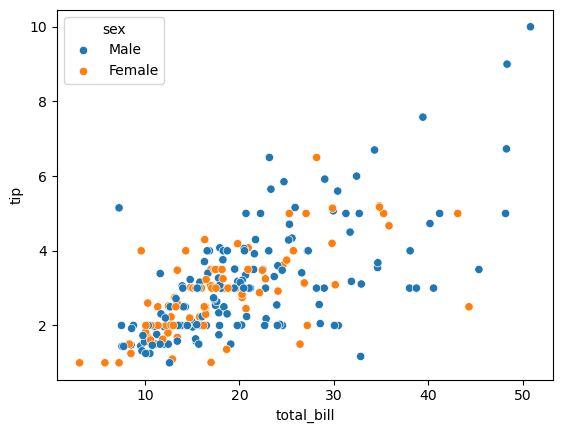

In [7]:
sns.scatterplot(data=df,x="total_bill",y="tip",hue="sex")

In [8]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='sex', ylabel='total_bill'>

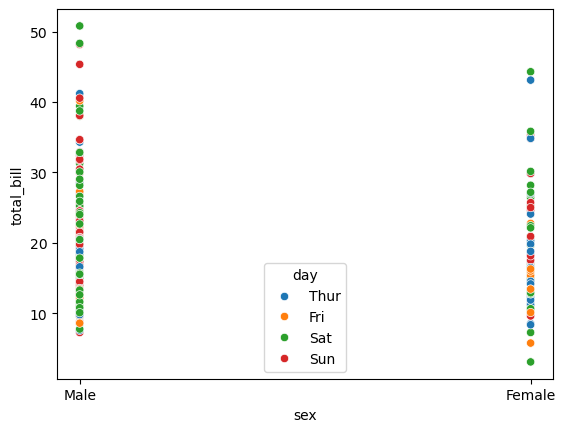

In [9]:
sns.scatterplot(data=df,y="total_bill",x="sex",hue="day")

<Axes: xlabel='smoker', ylabel='total_bill'>

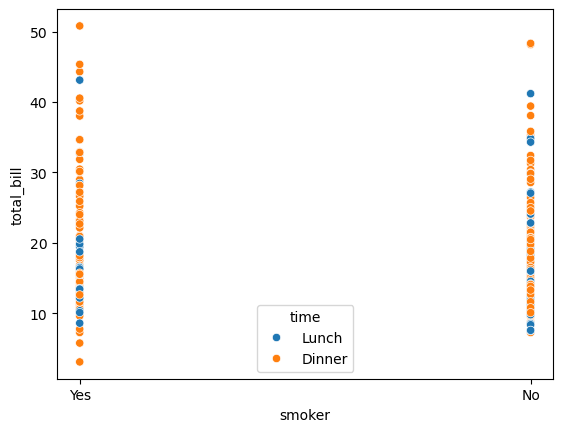

In [10]:
# plt.figure(figsize(5,5))
sns.scatterplot(data=df,y="total_bill",x="smoker",hue="time")

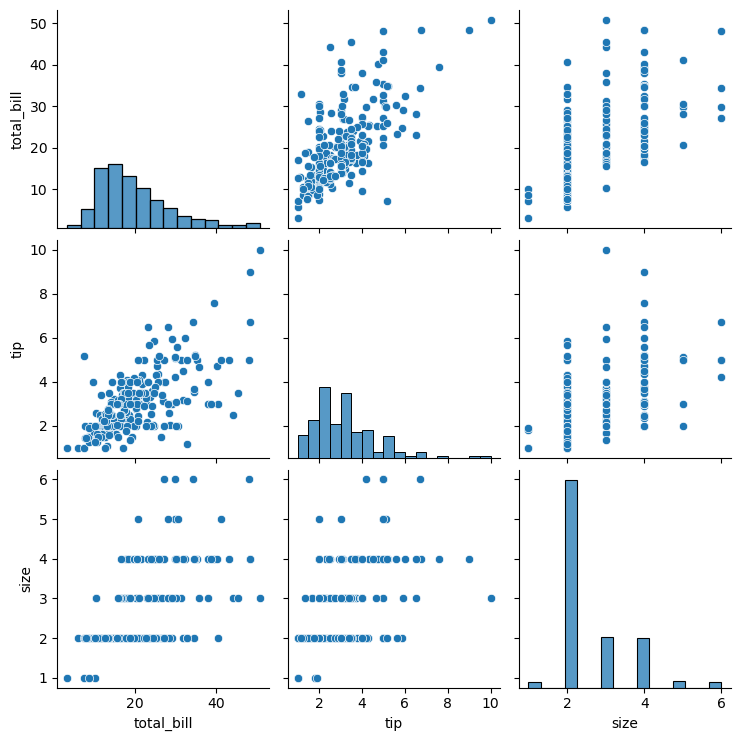

In [11]:
sns.pairplot(df)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [13]:
for i in df.columns:
    print(df[i].value_counts())

total_bill
13.42    3
21.01    2
20.69    2
10.33    2
10.34    2
        ..
29.03    1
27.18    1
22.67    1
17.82    1
18.78    1
Name: count, Length: 229, dtype: int64
tip
2.00    33
3.00    23
4.00    12
2.50    10
5.00    10
        ..
1.47     1
1.17     1
4.67     1
5.92     1
1.75     1
Name: count, Length: 123, dtype: int64
sex
Male      157
Female     87
Name: count, dtype: int64
smoker
No     151
Yes     93
Name: count, dtype: int64
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
time
Dinner    176
Lunch      68
Name: count, dtype: int64
size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64


In [14]:
# doing it manual
# Add this BEFORE splitting X and y

In [15]:
df["sex"]=df["sex"].map({"Male" :1,"Female" :0})
df["time"]=df["time"].map({"Dinner" :1,"Lunch" :0})
df["smoker"]=df["smoker"].map({"No" :0,"Yes" :1})
df = pd.get_dummies(df, columns=["day"], drop_first=True).astype(int)

In [16]:
df.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun
0,16,1,0,0,1,2,0,0,1
1,10,1,1,0,1,3,0,0,1
2,21,3,1,0,1,3,0,0,1
3,23,3,1,0,1,2,0,0,1
4,24,3,0,0,1,4,0,0,1


In [17]:
df.drop("day_Fri",axis=1,inplace=True)

In [18]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
time          0
size          0
day_Sat       0
day_Sun       0
dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [20]:
x=df.drop("tip",axis=1)
y=df["tip"]

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [22]:
model=RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1)

In [23]:
model.fit(x_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [24]:
pre=model.predict(x_test)

In [25]:
r2=r2_score(y_test,pre)
r2

0.3269447612154134

In [26]:
# Feature Importance
feature_imp = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
feature_imp

,Feature,Importance
0,total_bill,0.708943
2,smoker,0.083204
4,size,0.079690
6,day_Sun,0.037550
1,sex,0.034935
5,day_Sat,0.030792
3,time,0.024885


In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model2=LinearRegression()

In [29]:
model2.fit(x_train,y_train)

LinearRegression()

In [30]:
model2.score(x_test,y_test)

0.47008209983575844

In [31]:
pp2=model2.predict(x_test)

In [32]:
r2_score(y_test,pp2)

0.47008209983575844

In [33]:
from sklearn.linear_model import Ridge, Lasso

In [34]:
lasso = Lasso(alpha=0.4)
lasso.fit(x_train, y_train)
print(r2_score(y_test, lasso.predict(x_test)))
pre2=lasso.predict(x_test)
# pre2

0.5512524666023848


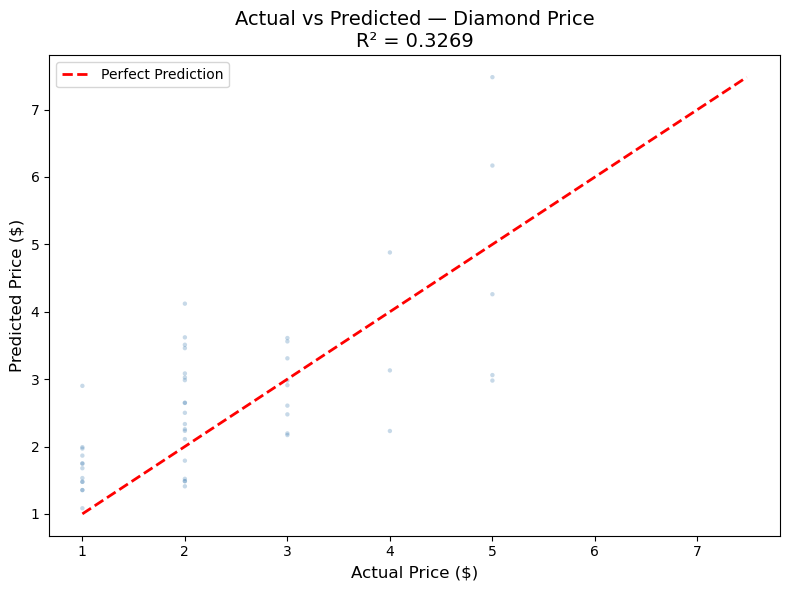

In [35]:
pre = model.predict(x_test)
r2  = r2_score(y_test, pre)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pre, alpha=0.3, color='steelblue', edgecolors='none', s=10)

min_val = min(y_test.min(), pre.min())
max_val = max(y_test.max(), pre.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title(f'Actual vs Predicted — Diamond Price\nR² = {r2:.4f}', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()